## Import Dependencies


In [1426]:
import random
import re
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Random State & Device Initialization


In [1427]:
SEED = 44
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: cpu


## Formatting


In [1428]:
PLOT_DPI = 165

COLORS = {
    "train": "#2563EB",
    "valid": "#F97316",
    "test": "#16A34A",
    "adam": "#2563EB",
    "lbfgs": "#9333EA",
    "data": "#0EA5E9",
    "physics": "#DC2626",
    "reflection": "#16A34A",
    "ideal": "#111827",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "purple": "#7C3AED",
    "amber": "#F59E0B",
}

SPLIT_COLORS = {
    "train": COLORS["train"],
    "valid": COLORS["valid"],
    "test": COLORS["test"],
}

plt.rcParams.update({
    "figure.figsize": (7.2, 4.4),
    "figure.dpi": PLOT_DPI,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11.5,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "semibold",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.edgecolor": "#D1D5DB",
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
    "grid.color": "#9CA3AF",
    "lines.linewidth": 2.1,
    "legend.frameon": True,
    "legend.framealpha": 0.94,
    "legend.edgecolor": "#E5E7EB",
})


def polish_axes(
    ax,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    legend: bool = False,
) -> None:
    if title is not None:
        ax.set_title(title, pad=11)
    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=7)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=7)

    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.7)
    ax.spines["bottom"].set_alpha(0.7)
    ax.tick_params(axis="both", which="major", length=4, width=0.8, color="#6B7280")

    if legend:
        leg = ax.legend()
        if leg is not None:
            leg.get_frame().set_facecolor("white")
            leg.get_frame().set_edgecolor("#E5E7EB")
            leg.get_frame().set_linewidth(0.9)
            leg.get_frame().set_alpha(0.95)


def smooth_series(values, window: int = 35) -> np.ndarray:
    return pd.Series(values).rolling(window=window, min_periods=1, center=False).mean().to_numpy()


def log10_safe(values, eps: float = 1e-16) -> np.ndarray:
    return np.log10(np.asarray(values).clip(min=eps))


def plot_density_hist(
    ax,
    values,
    *,
    bins: int = 80,
    color: str,
    label: str,
    alpha: float = 0.20,
    linewidth: float = 2.2,
) -> None:
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=alpha,
        color=color,
        edgecolor=color,
        linewidth=1.0,
        label=label,
    )
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        color=color,
        linewidth=linewidth,
    )


def plot_ecdf(
    ax,
    values,
    *,
    color: str,
    label: str,
    linewidth: float = 2.2,
) -> None:
    x = np.sort(np.asarray(values))
    y = np.linspace(0.0, 1.0, len(x), endpoint=True)
    ax.plot(x, y, color=color, linewidth=linewidth, label=label)


def compact_count(n: int) -> str:
    n = int(n)
    if n % 1000 == 0:
        return f"{n // 1000}k"
    return str(n)


def compact_float(value: float) -> str:
    value = float(value)
    if value == 0:
        return "0"
    if abs(value - round(value)) < 1e-12:
        return str(int(round(value)))
    text = f"{value:g}"
    return text.replace(".", "p").replace("-", "m").replace("+", "")


def save_current_figure(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")


def save_dataframe_as_png(df_to_save: pd.DataFrame, path: Path, title: str | None = None) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    display_df = df_to_save.copy()
    for col in display_df.columns:
        if pd.api.types.is_numeric_dtype(display_df[col]):
            display_df[col] = display_df[col].map(lambda x: f"{x:.6g}" if pd.notna(x) else "")

    fig_height = max(1.8, 0.42 * (len(display_df) + 1) + (0.35 if title else 0.0))
    fig_width = max(8.0, 1.35 * len(display_df.columns))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=180)
    ax.axis("off")
    if title is not None:
        ax.set_title(title, fontsize=12.5, fontweight="semibold", pad=10)

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1.0, 1.25)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#E5E7EB")
        cell.set_linewidth(0.7)
        if row == 0:
            cell.set_text_props(weight="semibold", color="#111827")
            cell.set_facecolor("#F3F4F6")
        else:
            cell.set_facecolor("white")

    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def save_dataframe_text(df_to_save: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(df_to_save.to_string(index=False), encoding="utf-8")

## Configuration


In [1429]:
@dataclass(frozen=True)
class Config:
    notebook_dir: Path = Path.cwd()
    project_root: Path = notebook_dir.parent if notebook_dir.name.lower() == "pinn" else notebook_dir

    data_path: Path = project_root / "storage" / "dataset_50k.csv"
    saved_models_dir: Path = (
        notebook_dir / "saved_models"
        if notebook_dir.name.lower() == "pinn"
        else project_root / "PINN" / "saved_models"
    )
    visualization_dir: Path = project_root / "visualization"

    load_existing_model: bool = False
    model_checkpoint_path: Path | None = None
    save_model_after_training: bool = True
    model_run_id: int | None = None

    add_noise: bool = True
    noise_level: float = 0.05
    noise_seed: int = 42

    valid_size: float = 0.15
    test_size: float = 0.15
    n_strat_bins: int = 10

    batch_size: int = 4096
    use_weighted_sampler: bool = True
    sampler_high_R_scale: float = 4.0

    max_epochs: int = 2000
    learning_rate: float = 5.0e-4
    weight_decay: float = 1.0e-6

    use_lbfgs: bool = True
    lbfgs_lr: float = 1.0
    lbfgs_max_iter: int = 5000
    lbfgs_max_eval: int = 7500
    lbfgs_history_size: int = 100
    lbfgs_tolerance_grad: float = 1.0e-9
    lbfgs_tolerance_change: float = 1.0e-11
    lbfgs_log_every: int = 10
    lbfgs_valid_log_every: int = 25

    R_loss_eps: float = 1.0e-6
    R_loss_log_weight: float = 0.85
    R_loss_sqrt_weight: float = 0.15

    patience: int = 200
    min_delta: float = 1.0e-8

    hidden_dim: int = 64
    num_hidden_layers: int = 3
    dropout: float = 0.0
    grad_clip_norm: float = 5.0
    scheduler_factor: float = 0.5
    scheduler_patience: int = 70

    plot_sample_size: int = 10_000
    relative_error_min_R: float = 1.0e-4


cfg = Config()

## Data Loading


In [1430]:
if not cfg.data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {cfg.data_path}"
    )

source_df = pd.read_csv(cfg.data_path)
required_columns = ["kappa", "R"]
missing = sorted(set(required_columns) - set(source_df.columns))
if missing:
    raise ValueError(f"Missing required columns in dataset: {missing}")

df = source_df.copy()
for col in ["kappa", "R"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["kappa", "R"])
df = df[(df["kappa"] > 0.0) & (df["R"] >= 0.0) & (df["R"] <= 1.0)].copy()
df = df.sort_values("kappa").drop_duplicates(subset="kappa").reset_index(drop=True)

if "logit_R" not in df.columns:
    R_clipped = df["R"].clip(cfg.R_loss_eps, 1.0 - cfg.R_loss_eps)
    df["logit_R"] = np.log(R_clipped / (1.0 - R_clipped))
else:
    df["logit_R"] = pd.to_numeric(df["logit_R"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["logit_R"]).reset_index(drop=True)

base_n_objects = len(df)
base_n_objects_tag = compact_count(base_n_objects)

noise_percent = int(round((cfg.noise_level if cfg.add_noise else 0.0) * 100))
model_dir = cfg.saved_models_dir / f"noise_{noise_percent}"
model_dir.mkdir(parents=True, exist_ok=True)

visualization_parent_dir = cfg.visualization_dir / f"noise_{noise_percent}" / base_n_objects_tag
visualization_parent_dir.mkdir(parents=True, exist_ok=True)

sampler_tag = f"ws{compact_float(cfg.sampler_high_R_scale)}" if cfg.use_weighted_sampler else "plain"

base_model_name = (
    f"pinn_{sampler_tag}_N{base_n_objects_tag}_"
    f"h{cfg.hidden_dim}x{cfg.num_hidden_layers}_"
    f"bs{cfg.batch_size}_ep{cfg.max_epochs}_"
    f"lr{compact_float(cfg.learning_rate)}"
)


def extract_run_id_from_checkpoint(path: Path) -> int | None:
    match = re.search(r"_m(\d+)\.pt$", path.name)
    return int(match.group(1)) if match else None


def existing_model_run_ids(model_dir: Path, base_name: str) -> list[int]:
    pattern = re.compile(rf"^{re.escape(base_name)}_m(\d+)\.pt$")
    run_ids = []
    for path in model_dir.glob(f"{base_name}_m*.pt"):
        match = pattern.match(path.name)
        if match:
            run_ids.append(int(match.group(1)))
    return run_ids


def existing_visualization_run_ids(parent_dir: Path) -> list[int]:
    if not parent_dir.exists():
        return []
    return [
        int(path.name)
        for path in parent_dir.iterdir()
        if path.is_dir() and path.name.isdigit()
    ]


def resolve_run_id() -> int:
    if cfg.load_existing_model:
        if cfg.model_checkpoint_path is None:
            raise ValueError("Set cfg.model_checkpoint_path when cfg.load_existing_model=True")

        checkpoint_run_id = extract_run_id_from_checkpoint(Path(cfg.model_checkpoint_path))
        if cfg.model_run_id is not None:
            return cfg.model_run_id
        if checkpoint_run_id is not None:
            return checkpoint_run_id
        return 1

    if cfg.model_run_id is not None:
        return cfg.model_run_id

    used_ids = (
        existing_model_run_ids(model_dir, base_model_name)
        + existing_visualization_run_ids(visualization_parent_dir)
    )
    return max(used_ids, default=0) + 1


resolved_model_run_id = resolve_run_id()
model_path = model_dir / f"{base_model_name}_m{resolved_model_run_id:02d}.pt"
checkpoint_path = Path(cfg.model_checkpoint_path) if cfg.model_checkpoint_path is not None else model_path

visualization_run_dir = visualization_parent_dir / f"{resolved_model_run_id:02d}"
visualization_run_dir.mkdir(parents=True, exist_ok=True)

## Data Distribution


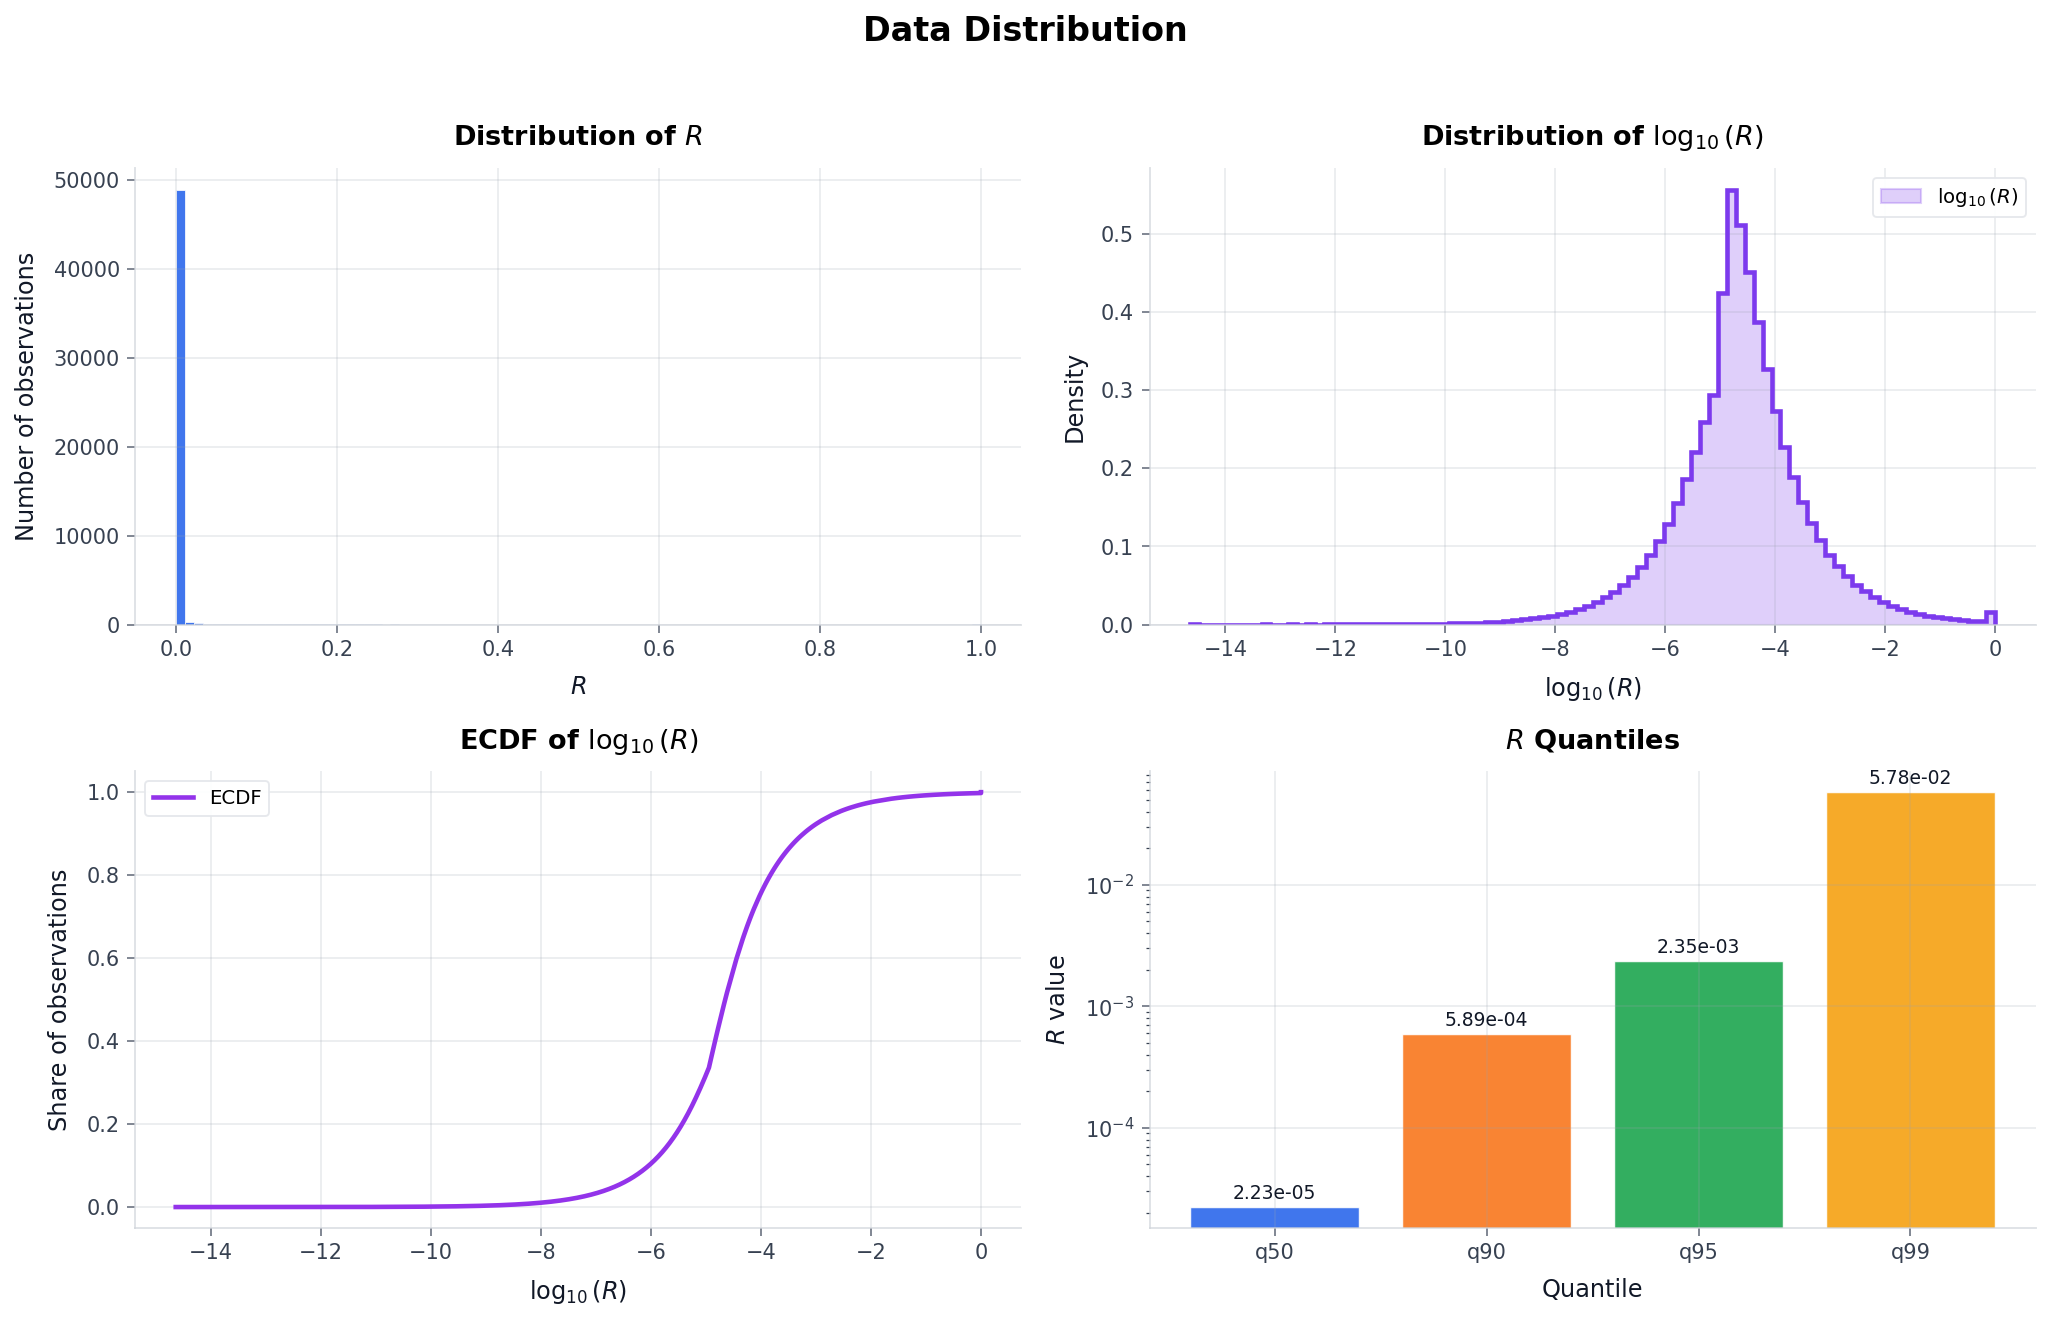

In [1431]:
R_values = df["R"].to_numpy()
log_R_values = log10_safe(R_values)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.6), dpi=150)
fig.suptitle("Data Distribution", fontsize=16, fontweight="semibold", y=1.02)

axes[0, 0].hist(
    R_values,
    bins=90,
    color=COLORS["train"],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.4,
)
polish_axes(
    axes[0, 0],
    "Distribution of $R$",
    "$R$",
    "Number of observations",
)

plot_density_hist(
    axes[0, 1],
    log_R_values,
    bins=90,
    color=COLORS["purple"],
    label=r"$\log_{10}(R)$",
    alpha=0.24,
)
polish_axes(
    axes[0, 1],
    r"Distribution of $\log_{10}(R)$",
    r"$\log_{10}(R)$",
    "Density",
    legend=True,
)

plot_ecdf(
    axes[1, 0],
    log_R_values,
    color=COLORS["lbfgs"],
    label="ECDF",
)
polish_axes(
    axes[1, 0],
    r"ECDF of $\log_{10}(R)$",
    r"$\log_{10}(R)$",
    "Share of observations",
    legend=True,
)

quantile_levels = np.array([0.50, 0.90, 0.95, 0.99])
quantile_values = np.quantile(R_values, quantile_levels)

axes[1, 1].bar(
    [f"q{int(q * 100)}" for q in quantile_levels],
    quantile_values,
    color=[COLORS["train"], COLORS["valid"], COLORS["test"], COLORS["amber"]],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.7,
)
axes[1, 1].set_yscale("log")
for i, val in enumerate(quantile_values):
    axes[1, 1].text(
        i,
        val * 1.08,
        f"{val:.2e}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#111827",
    )
polish_axes(
    axes[1, 1],
    "$R$ Quantiles",
    "Quantile",
    "$R$ value",
)

plt.tight_layout()
plt.show()

## Features and Target


In [1432]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({"kappa": data["kappa"].to_numpy(dtype=float)}, index=data.index)


feature_cols = ["kappa"]
target_cols = ["logit_R"]

X_raw = build_features(df)[feature_cols]
y_raw = df[target_cols].copy()
R_raw = df["R"].to_numpy(dtype=float)

## Train / Validation / Test Split


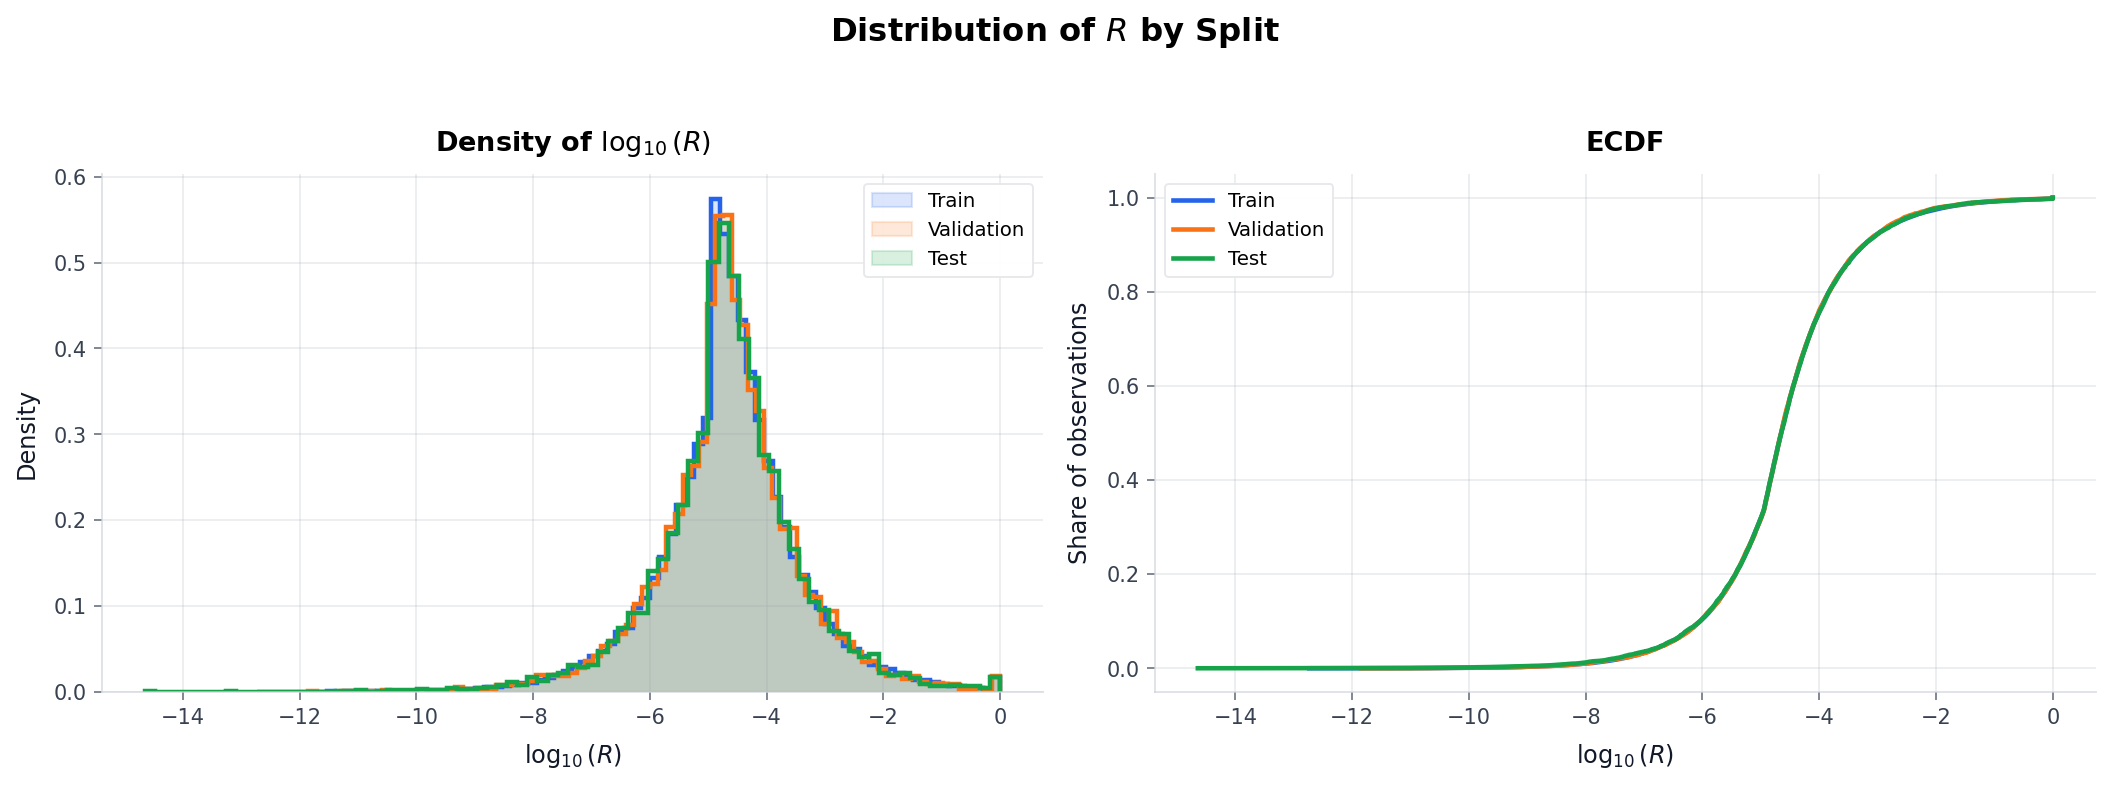

In [1433]:
df_split = df.copy()
df_split["log_R"] = np.log1p(df_split["R"])
df_split["R_bin"] = pd.qcut(
    df_split["log_R"],
    q=cfg.n_strat_bins,
    labels=False,
    duplicates="drop",
)

idx = np.arange(len(df_split))
strat_labels = df_split["R_bin"].astype(int).values

idx_train, idx_temp = train_test_split(
    idx,
    test_size=cfg.valid_size + cfg.test_size,
    random_state=SEED,
    stratify=strat_labels,
)

temp_test_fraction = cfg.test_size / (cfg.valid_size + cfg.test_size)
idx_valid, idx_test = train_test_split(
    idx_temp,
    test_size=temp_test_fraction,
    random_state=SEED,
    stratify=strat_labels[idx_temp],
)

X_train_raw = X_raw.iloc[idx_train].reset_index(drop=True)
X_valid_raw = X_raw.iloc[idx_valid].reset_index(drop=True)
X_test_raw = X_raw.iloc[idx_test].reset_index(drop=True)

y_train_raw = y_raw.iloc[idx_train].reset_index(drop=True)
y_valid_raw = y_raw.iloc[idx_valid].reset_index(drop=True)
y_test_raw = y_raw.iloc[idx_test].reset_index(drop=True)

R_train_raw = R_raw[idx_train]
R_valid_raw = R_raw[idx_valid]
R_test_raw = R_raw[idx_test]

split_parts = {
    "train": pd.DataFrame({"R": R_train_raw}),
    "valid": pd.DataFrame({"R": R_valid_raw}),
    "test": pd.DataFrame({"R": R_test_raw}),
}

split_labels = {
    "train": "Train",
    "valid": "Validation",
    "test": "Test",
}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), dpi=150)
fig.suptitle("Distribution of $R$ by Split", fontsize=15.5, fontweight="semibold", y=1.04)

for name, part in split_parts.items():
    log_r = log10_safe(part["R"].to_numpy())
    color = SPLIT_COLORS[name]
    label = split_labels[name]

    plot_density_hist(
        axes[0],
        log_r,
        bins=85,
        color=color,
        label=label,
        alpha=0.16,
        linewidth=2.15,
    )

    plot_ecdf(
        axes[1],
        log_r,
        color=color,
        label=label,
        linewidth=2.2,
    )

polish_axes(
    axes[0],
    r"Density of $\log_{10}(R)$",
    r"$\log_{10}(R)$",
    "Density",
    legend=True,
)

polish_axes(
    axes[1],
    "ECDF",
    r"$\log_{10}(R)$",
    "Share of observations",
    legend=True,
)

plt.tight_layout()
plt.show()

## Noise Application


In [1434]:
def make_logit_R_np(values: np.ndarray, eps: float) -> np.ndarray:
    clipped = np.clip(np.asarray(values, dtype=float), eps, 1.0 - eps)
    return np.log(clipped / (1.0 - clipped))


def add_gaussian_noise_to_R(R_values: np.ndarray, noise_level: float, seed: int) -> np.ndarray:
    if noise_level <= 0:
        return R_values.copy()

    rng = np.random.default_rng(seed)
    R_values = np.asarray(R_values, dtype=float)
    noise = rng.normal(loc=0.0, scale=noise_level, size=len(R_values))
    noisy = R_values * (1.0 + noise)

    return np.clip(noisy, cfg.R_loss_eps, 1.0 - cfg.R_loss_eps)


if cfg.add_noise and cfg.noise_level > 0:
    R_train_noisy = add_gaussian_noise_to_R(R_train_raw, cfg.noise_level, cfg.noise_seed)
    y_train_raw = pd.DataFrame({"logit_R": make_logit_R_np(R_train_noisy, cfg.R_loss_eps)})
    R_train_for_loss = R_train_noisy
else:
    R_train_for_loss = R_train_raw.copy()

## Normalization


In [1435]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_valid = x_scaler.transform(X_valid_raw)
X_test = x_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_valid = y_scaler.transform(y_valid_raw)
y_test = y_scaler.transform(y_test_raw)

y_mean_t = torch.tensor(y_scaler.mean_, dtype=torch.float32, device=device)
y_scale_t = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=device)

## Data Loader


In [1436]:
def to_float_tensor(array_like) -> torch.Tensor:
    return torch.tensor(np.asarray(array_like), dtype=torch.float32)


X_train_t = to_float_tensor(X_train)
y_train_t = to_float_tensor(y_train)
R_train_t = to_float_tensor(R_train_for_loss).reshape(-1, 1)

X_valid_t = to_float_tensor(X_valid).to(device)
y_valid_t = to_float_tensor(y_valid).to(device)
R_valid_t = to_float_tensor(R_valid_raw).reshape(-1, 1).to(device)

X_test_t = to_float_tensor(X_test).to(device)
y_test_t = to_float_tensor(y_test).to(device)
R_test_t = to_float_tensor(R_test_raw).reshape(-1, 1).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t, R_train_t)

if cfg.use_weighted_sampler:
    weights = np.ones(len(R_train_for_loss), dtype=np.float64)
    weights += cfg.sampler_high_R_scale * np.clip(R_train_for_loss, 0.0, 1.0)
    weights += 2.0 * cfg.sampler_high_R_scale * (R_train_for_loss > 0.01).astype(np.float64)
    weights += 4.0 * cfg.sampler_high_R_scale * (R_train_for_loss > 0.05).astype(np.float64)
    weights /= weights.mean()
    sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
    shuffle = False
else:
    sampler = None
    shuffle = True

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    sampler=sampler,
    shuffle=shuffle,
    pin_memory=(device.type == "cuda"),
)

full_train = (
    X_train_t.to(device),
    y_train_t.to(device),
    R_train_t.to(device),
)

## PINN Architecture


In [1437]:
class PhysicsInformedNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_hidden_layers: int, dropout: float = 0.0):
        super().__init__()

        layers: list[nn.Module] = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        for _ in range(num_hidden_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.Tanh()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = PhysicsInformedNN(
    input_dim=len(feature_cols),
    hidden_dim=cfg.hidden_dim,
    num_hidden_layers=cfg.num_hidden_layers,
    dropout=cfg.dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", n_params)

PhysicsInformedNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 8513


## Training & Loss Functions


In [1438]:
def clone_state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def unscale_logit_R(pred_scaled: torch.Tensor) -> torch.Tensor:
    return pred_scaled * y_scale_t + y_mean_t


def R_from_scaled_logit(pred_scaled: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(unscale_logit_R(pred_scaled))


def R_loss(pred_scaled: torch.Tensor, target_scaled: torch.Tensor, R_true: torch.Tensor) -> torch.Tensor:
    R_pred = R_from_scaled_logit(pred_scaled)
    loss_logit = F.smooth_l1_loss(pred_scaled, target_scaled)
    loss_R = F.smooth_l1_loss(R_pred, R_true)
    loss_sqrt = F.smooth_l1_loss(
        torch.sqrt(torch.clamp(R_pred, min=cfg.R_loss_eps)),
        torch.sqrt(torch.clamp(R_true, min=cfg.R_loss_eps)),
    )
    return cfg.R_loss_log_weight * loss_logit + loss_R + cfg.R_loss_sqrt_weight * loss_sqrt


@torch.no_grad()
def evaluate_loss(model: nn.Module, X: torch.Tensor, y: torch.Tensor, R_true: torch.Tensor) -> float:
    model.eval()
    pred = model(X)
    return float(R_loss(pred, y, R_true).detach().cpu())


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray, rel_eps: float = 1.0e-8) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    denom = np.maximum(np.abs(y_true), rel_eps)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "rMAE": float(np.mean(np.abs(err) / denom)),
        "rRMSE": float(np.sqrt(np.mean((err / denom) ** 2))),
    }

## Load Model

In [1439]:
model_was_loaded = False
checkpoint_path = None

if cfg.load_existing_model:
    checkpoint_path = cfg.model_checkpoint_path if cfg.model_checkpoint_path is not None else model_path
    if checkpoint_path is None or not Path(checkpoint_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model_was_loaded = True
    print(f"Loaded checkpoint: {checkpoint_path}")

## Training AdamW


In [1440]:
history = []
best_valid = float("inf")
best_state_dict = clone_state_dict_to_cpu(model)
best_stage = "init"
best_epoch = 0
epochs_without_improvement = 0

if not model_was_loaded:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=cfg.scheduler_factor,
        patience=cfg.scheduler_patience,
    )

    adam_bar = tqdm(
        range(1, cfg.max_epochs + 1),
        desc="AdamW",
        unit="epoch",
        dynamic_ncols=True,
    )

    for epoch in adam_bar:
        model.train()
        batch_losses = []

        for bx, by, bR in train_loader:
            bx = bx.to(device)
            by = by.to(device)
            bR = bR.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(bx)
            loss = R_loss(pred, by, bR)
            loss.backward()

            if cfg.grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)

            optimizer.step()
            batch_losses.append(float(loss.detach().cpu()))

        train_loss = float(np.mean(batch_losses))
        valid_loss = evaluate_loss(model, X_valid_t, y_valid_t, R_valid_t)
        scheduler.step(valid_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        history.append({
            "stage": "adam",
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "lr": current_lr,
        })

        if valid_loss < best_valid - cfg.min_delta:
            best_valid = valid_loss
            best_state_dict = clone_state_dict_to_cpu(model)
            best_stage = "adam"
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        adam_bar.set_postfix(
            train=f"{train_loss:.2e}",
            valid=f"{valid_loss:.2e}",
            best=f"{best_valid:.2e}",
            lr=f"{current_lr:.1e}",
        )

        if epochs_without_improvement >= cfg.patience:
            tqdm.write(f"Stopping at Epoch {epoch}. Best Epoch: {best_epoch}")
            break

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)
print(f"Best Adam Validation Loss: {best_valid:.6e} at Epoch {best_epoch}")


AdamW:   0%|          | 0/2000 [00:00<?, ?epoch/s]

Best Adam Validation Loss: 3.484300e-03 at Epoch 1987


## Plot AdamW


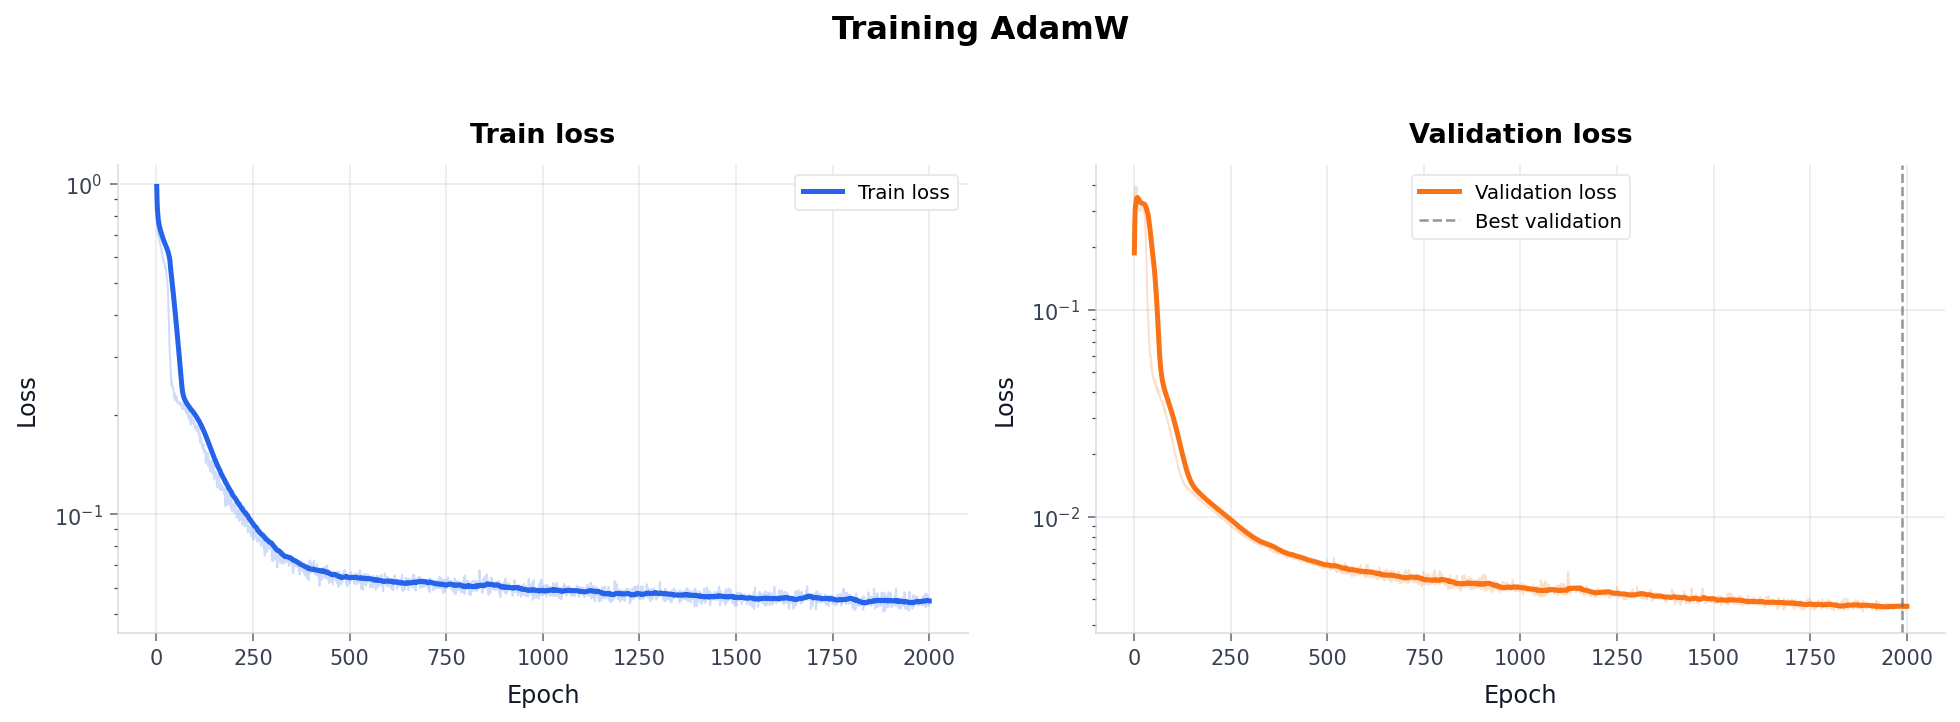

In [1441]:
adam_history = history_df[history_df["stage"] == "adam"].copy() if len(history_df) else pd.DataFrame()

if len(adam_history) == 0:
    print("AdamW history is empty")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), dpi=150)
    fig.suptitle("Training AdamW", fontsize=15.5, fontweight="semibold", y=1.04)

    epoch = adam_history["epoch"].to_numpy()
    train_loss = adam_history["train_loss"].to_numpy()
    valid_loss = adam_history["valid_loss"].to_numpy()

    axes[0].plot(epoch, train_loss, color=COLORS["train"], alpha=0.22, linewidth=1.0)
    axes[0].plot(epoch, smooth_series(train_loss, 35), color=COLORS["train"], linewidth=2.4, label="Train loss")
    axes[0].set_yscale("log")
    polish_axes(axes[0], "Train loss", "Epoch", "Loss", legend=True)

    axes[1].plot(epoch, valid_loss, color=COLORS["valid"], alpha=0.22, linewidth=1.0)
    axes[1].plot(epoch, smooth_series(valid_loss, 35), color=COLORS["valid"], linewidth=2.4, label="Validation loss")
    axes[1].axvline(
        adam_history.loc[adam_history["valid_loss"].idxmin(), "epoch"],
        color=COLORS["gray"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Best validation",
    )
    axes[1].set_yscale("log")
    polish_axes(axes[1], "Validation loss", "Epoch", "Loss", legend=True)

    plt.tight_layout()
    plt.show()

## Training L-BFGS


In [1442]:
lbfgs_trace = []

if cfg.use_lbfgs and not model_was_loaded:
    model.load_state_dict(best_state_dict)
    model.train()

    X_full, y_full, R_full = full_train
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=cfg.lbfgs_lr,
        max_iter=cfg.lbfgs_max_iter,
        max_eval=cfg.lbfgs_max_eval,
        history_size=cfg.lbfgs_history_size,
        tolerance_grad=cfg.lbfgs_tolerance_grad,
        tolerance_change=cfg.lbfgs_tolerance_change,
        line_search_fn="strong_wolfe",
    )

    lbfgs_state = {
        "iteration": 0,
        "best_valid": best_valid,
        "best_state_dict": best_state_dict,
        "best_stage": best_stage,
        "last_valid": np.nan,
    }

    lbfgs_bar = tqdm(
        total=cfg.lbfgs_max_eval,
        desc="L-BFGS",
        unit="eval",
        dynamic_ncols=True,
    )

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        pred = model(X_full)
        loss = R_loss(pred, y_full, R_full)
        loss.backward()

        lbfgs_state["iteration"] += 1
        iteration = lbfgs_state["iteration"]
        train_value = float(loss.detach().cpu())

        if iteration % cfg.lbfgs_valid_log_every == 0 or iteration == 1:
            valid_value = evaluate_loss(model, X_valid_t, y_valid_t, R_valid_t)
            lbfgs_state["last_valid"] = valid_value

            if valid_value < lbfgs_state["best_valid"] - cfg.min_delta:
                lbfgs_state["best_valid"] = valid_value
                lbfgs_state["best_state_dict"] = clone_state_dict_to_cpu(model)
                lbfgs_state["best_stage"] = "lbfgs"
        else:
            valid_value = np.nan

        if iteration % cfg.lbfgs_log_every == 0 or iteration == 1:
            lbfgs_trace.append({
                "iteration": iteration,
                "train_loss": train_value,
                "valid_loss": valid_value,
            })

        if lbfgs_bar.n < lbfgs_bar.total:
            lbfgs_bar.update(1)

        if iteration == 1 or iteration % cfg.lbfgs_log_every == 0:
            postfix = {
                "train": f"{train_value:.2e}",
                "best": f"{lbfgs_state['best_valid']:.2e}",
            }
            if np.isfinite(lbfgs_state["last_valid"]):
                postfix["valid"] = f"{lbfgs_state['last_valid']:.2e}"
            lbfgs_bar.set_postfix(**postfix)

        return loss

    optimizer_lbfgs.step(closure)
    lbfgs_bar.close()

    best_valid = lbfgs_state["best_valid"]
    best_state_dict = lbfgs_state["best_state_dict"]
    best_stage = lbfgs_state["best_stage"]
    model.load_state_dict(best_state_dict)

    train_metrics_after_lbfgs = evaluate_loss(model, full_train[0], full_train[1], full_train[2])
    valid_metrics_after_lbfgs = evaluate_loss(model, X_valid_t, y_valid_t, R_valid_t)
    print(f"L-BFGS Final Train Loss: {train_metrics_after_lbfgs:.6e}")
    print(f"L-BFGS Final Valid Loss: {valid_metrics_after_lbfgs:.6e}")
else:
    print("L-BFGS skipped")

print(f"\nSelected Stage: {best_stage}")
print(f"Best Validation Loss After All Stages: {best_valid:.6e}")

L-BFGS:   0%|          | 0/7500 [00:00<?, ?eval/s]

L-BFGS Final Train Loss: 2.673810e-03
L-BFGS Final Valid Loss: 3.363048e-03

Selected Stage: lbfgs
Best Validation Loss After All Stages: 3.363048e-03


## Plot L-BFGS


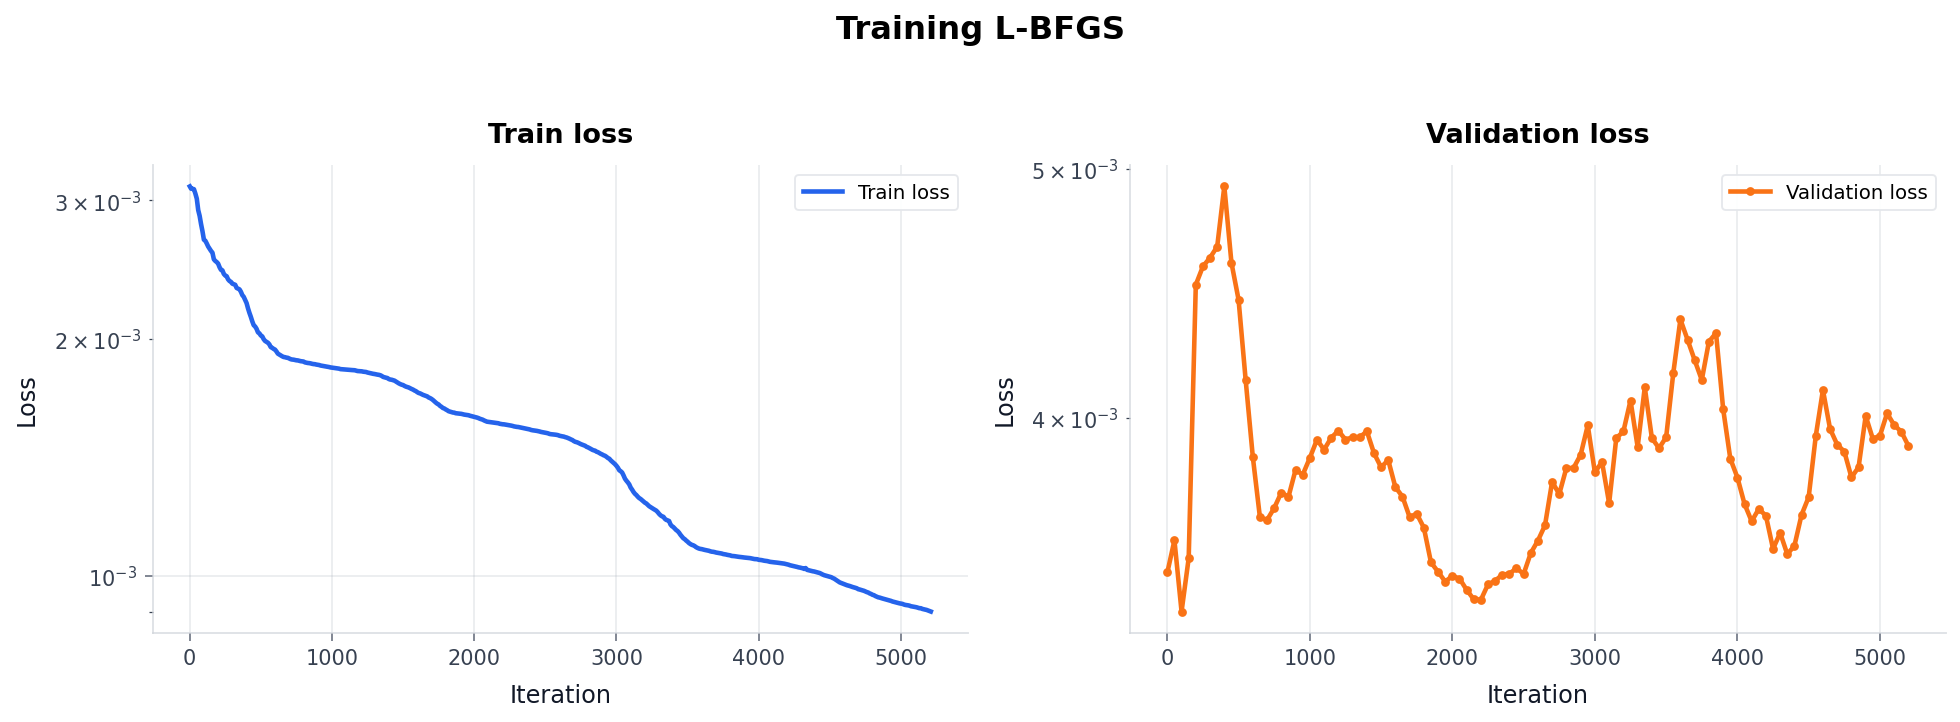

In [1443]:
lbfgs_trace_df = pd.DataFrame(lbfgs_trace)

if len(lbfgs_trace_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), dpi=150)
    fig.suptitle("Training L-BFGS", fontsize=15.5, fontweight="semibold", y=1.04)

    axes[0].plot(
        lbfgs_trace_df["iteration"],
        lbfgs_trace_df["train_loss"],
        color=COLORS["train"],
        linewidth=2.2,
        label="Train loss",
    )
    axes[0].set_yscale("log")
    polish_axes(axes[0], "Train loss", "Iteration", "Loss", legend=True)

    valid_trace = lbfgs_trace_df.dropna(subset=["valid_loss"])
    if len(valid_trace) > 0:
        axes[1].plot(
            valid_trace["iteration"],
            valid_trace["valid_loss"],
            color=COLORS["valid"],
            linewidth=2.2,
            marker="o",
            markersize=3.2,
            label="Validation loss",
        )
        axes[1].set_yscale("log")
        polish_axes(axes[1], "Validation loss", "Iteration", "Loss", legend=True)
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "No validation points logged", ha="center", va="center", color=COLORS["gray"])

    plt.tight_layout()
    plt.show()
else:
    print("L-BFGS trace is empty")

## Test Prediction


In [1444]:
@torch.no_grad()
def predict_R_dataset(model: nn.Module, X_tensor: torch.Tensor) -> np.ndarray:
    model.eval()
    pred_scaled = model(X_tensor)
    R_pred = R_from_scaled_logit(pred_scaled)
    return R_pred.detach().cpu().numpy().reshape(-1)


model.load_state_dict(best_state_dict)
R_train_pred = predict_R_dataset(model, full_train[0])
R_valid_pred = predict_R_dataset(model, X_valid_t)
R_test_pred = predict_R_dataset(model, X_test_t)

R_true_train = R_train_raw
R_true_valid = R_valid_raw
R_true_test = R_test_raw

## Metrics


In [1445]:
metrics_rows = []
for split_name, y_true, y_pred in [
    ("train", R_true_train, R_train_pred),
    ("valid", R_true_valid, R_valid_pred),
    ("test", R_true_test, R_test_pred),
]:
    m = regression_metrics(y_true, y_pred, rel_eps=cfg.relative_error_min_R)
    metrics_rows.append({
        "Split": split_name,
        "Target": "R",
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "rMAE, %": 100.0 * m["rMAE"],
        "rRMSE, %": 100.0 * m["rRMSE"],
    })

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

save_dataframe_text(metrics_df, visualization_run_dir / "metrics.txt")
save_dataframe_as_png(metrics_df, visualization_run_dir / "metrics.png", title="Metrics")

,Split,Target,MAE,RMSE,"rMAE, %","rRMSE, %"
0,train,R,0.000232,0.003683,1.251341,2.488910
1,valid,R,0.000201,0.003491,1.218380,2.416748
2,test,R,0.000260,0.004050,1.248763,2.481798


## Prediction Visualization


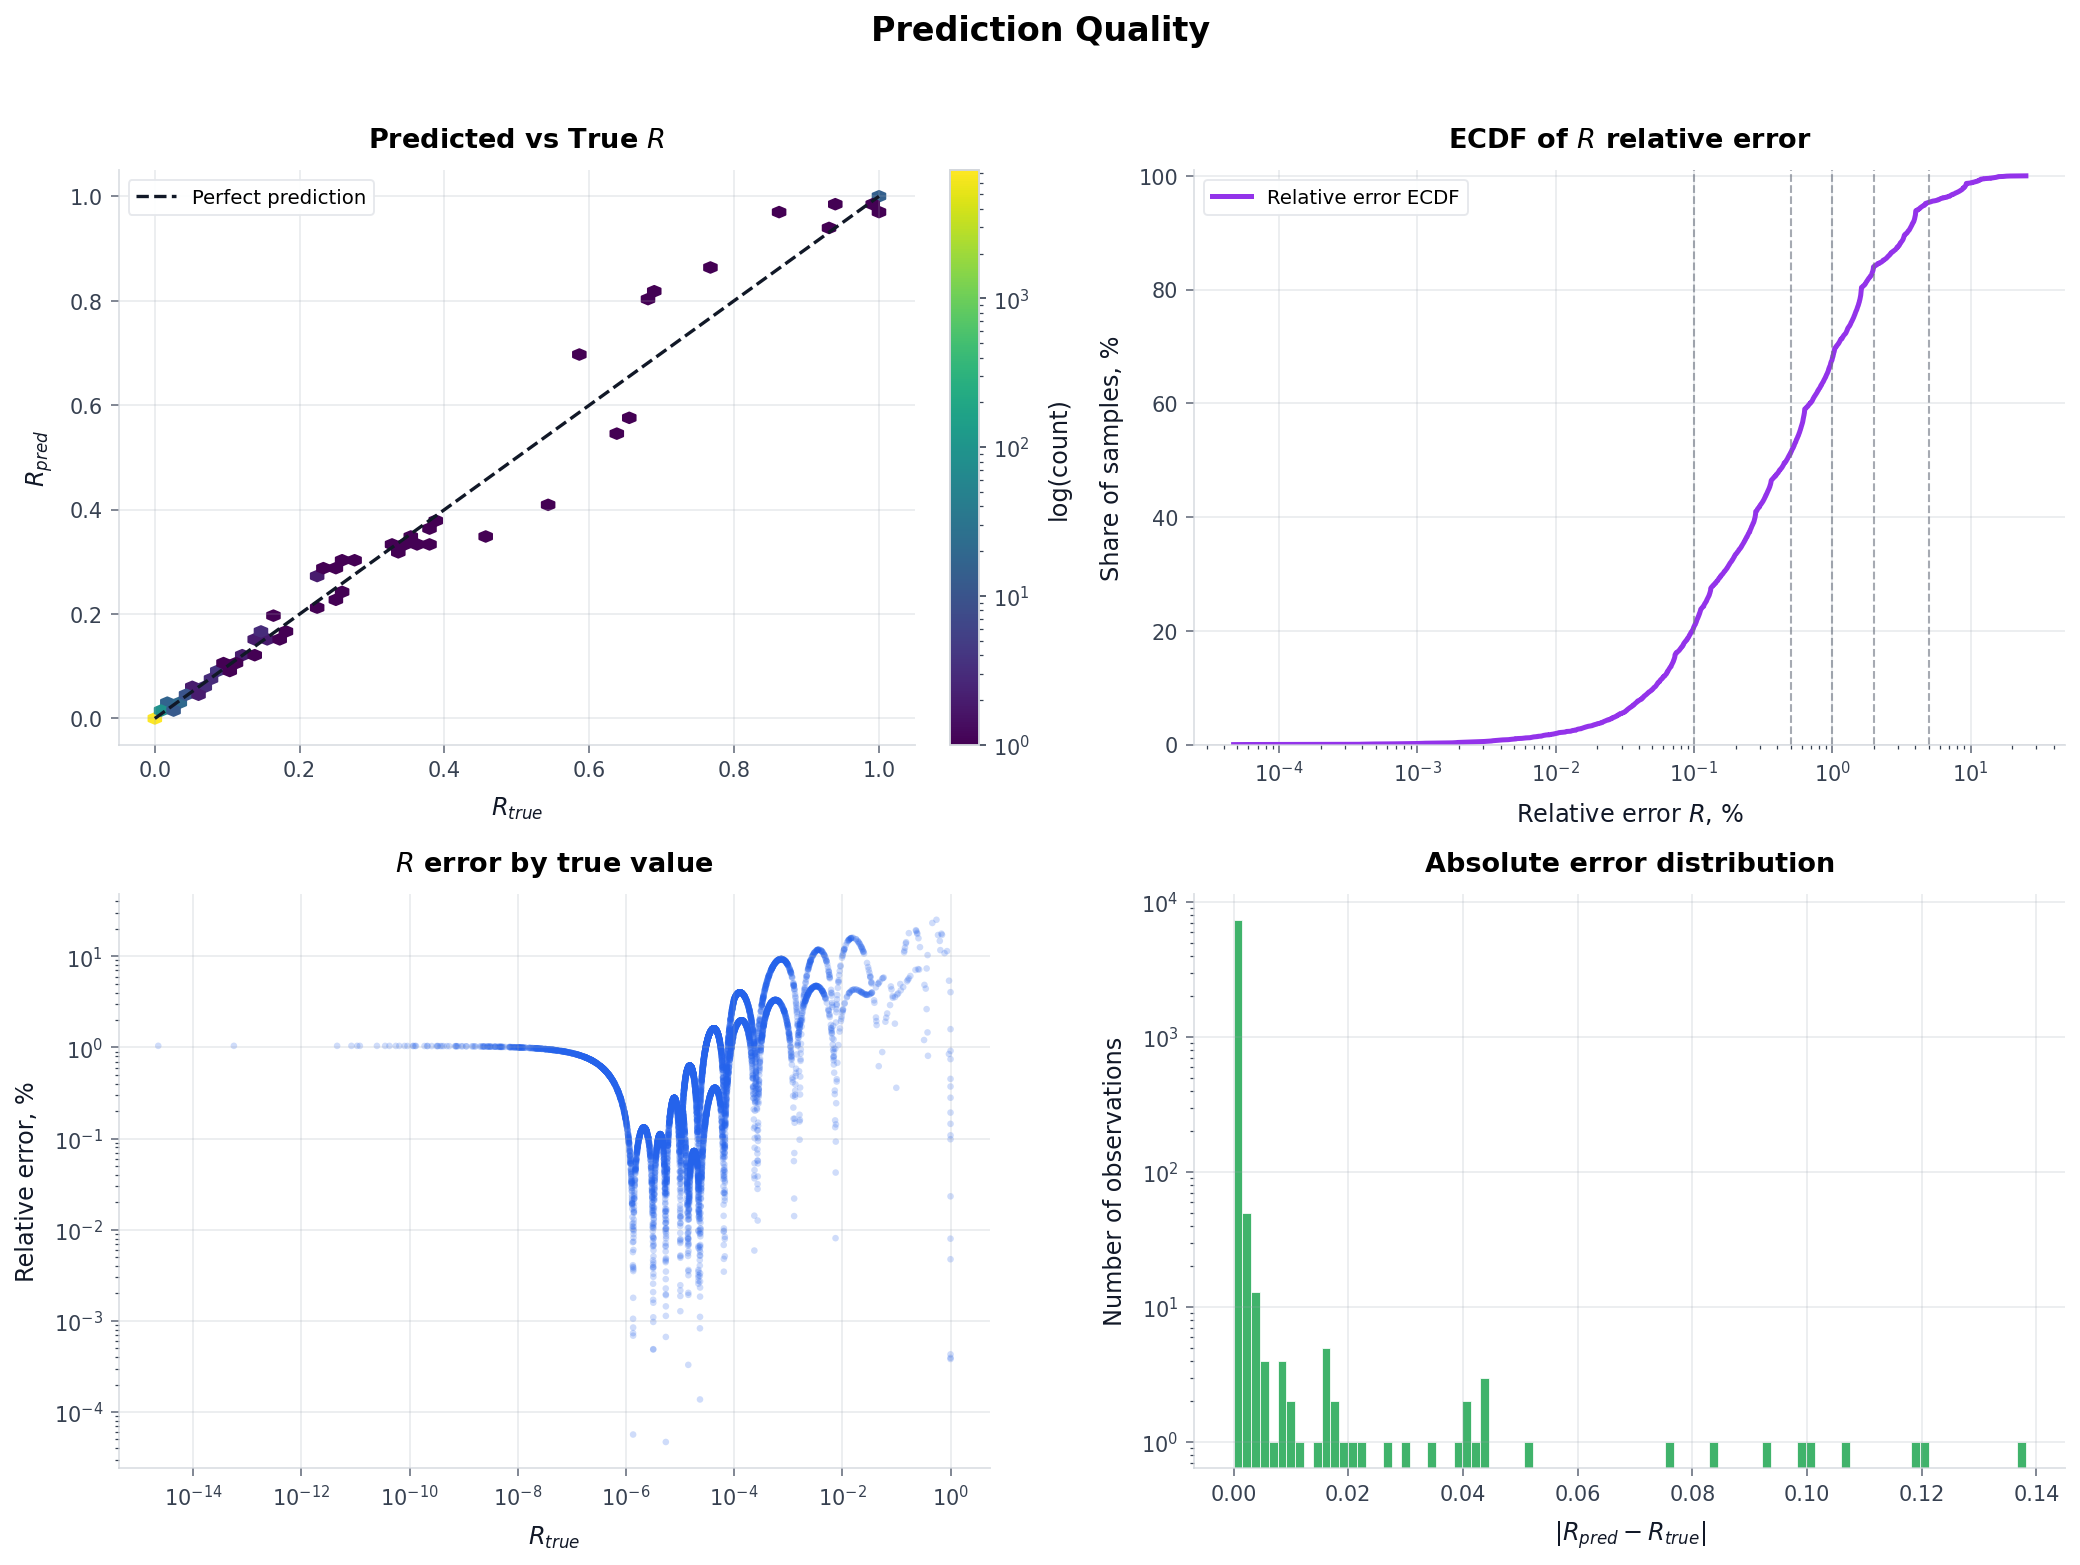

In [1446]:
rng = np.random.default_rng(SEED)
plot_count = min(cfg.plot_sample_size, len(R_true_test))
plot_idx = rng.choice(len(R_true_test), size=plot_count, replace=False)

abs_error_R = np.abs(R_test_pred - R_true_test)
rel_error_R_pct_all = 100.0 * abs_error_R / np.maximum(np.abs(R_true_test), cfg.relative_error_min_R)
mask_rel = R_true_test >= cfg.relative_error_min_R

fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2), dpi=150)
fig.suptitle("Prediction Quality", fontsize=16, fontweight="semibold", y=1.02)

hb = axes[0, 0].hexbin(
    R_true_test[plot_idx],
    R_test_pred[plot_idx],
    gridsize=58,
    bins="log",
    mincnt=1,
    cmap="viridis",
)
min_v = min(float(R_true_test.min()), float(R_test_pred.min()))
max_v = max(float(R_true_test.max()), float(R_test_pred.max()))
axes[0, 0].plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1.6, color=COLORS["ideal"], label="Perfect prediction")
polish_axes(axes[0, 0], "Predicted vs True $R$", r"$R_{true}$", r"$R_{pred}$", legend=True)
cb = fig.colorbar(hb, ax=axes[0, 0], fraction=0.046, pad=0.04)
cb.set_label("log(count)", labelpad=8)

rel_errors = rel_error_R_pct_all[np.isfinite(rel_error_R_pct_all)]
rel_sorted = np.sort(rel_errors)
rel_ecdf = np.linspace(0.0, 100.0, len(rel_sorted), endpoint=True)

axes[0, 1].plot(rel_sorted, rel_ecdf, color=COLORS["lbfgs"], linewidth=2.4, label="Relative error ECDF")
for threshold in [0.1, 0.5, 1.0, 2.0, 5.0]:
    if len(rel_sorted) and threshold <= np.nanmax(rel_sorted):
        axes[0, 1].axvline(threshold, linestyle="--", linewidth=1.0, alpha=0.6, color=COLORS["gray"])
axes[0, 1].set_xscale("log")
axes[0, 1].set_ylim(0, 101)
polish_axes(axes[0, 1], "ECDF of $R$ relative error", "Relative error $R$, %", "Share of samples, %", legend=True)

plot_mask = np.isfinite(rel_error_R_pct_all[plot_idx])
axes[1, 0].scatter(
    R_true_test[plot_idx][plot_mask],
    rel_error_R_pct_all[plot_idx][plot_mask],
    s=10,
    alpha=0.22,
    color=COLORS["train"],
    edgecolors="none",
    label="Test points",
)

axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
polish_axes(axes[1, 0], "$R$ error by true value", r"$R_{true}$", "Relative error, %")

axes[1, 1].hist(
    abs_error_R,
    bins=90,
    color=COLORS["reflection"],
    alpha=0.82,
    edgecolor="white",
    linewidth=0.45,
)
axes[1, 1].set_yscale("log")
polish_axes(axes[1, 1], "Absolute error distribution", r"$|R_{pred}-R_{true}|$", "Number of observations")

plt.tight_layout()
save_current_figure(visualization_run_dir / "prediction_quality.png")
plt.show()

## Relative Error


,R_range,count,mean_error_percent,median_error_percent,share_error_below_1pct
0,"$[10^{-4}, 10^{-3}]$",1250,3.042042,2.495787,12.560000
1,"$(10^{-3}, 10^{-2}]$",405,4.106474,3.698045,15.802469
2,"$(10^{-2}, 10^{-1}]$",114,7.210286,4.451537,2.631579
3,"$(10^{-1}, 1]$",60,7.437848,5.351591,28.333333


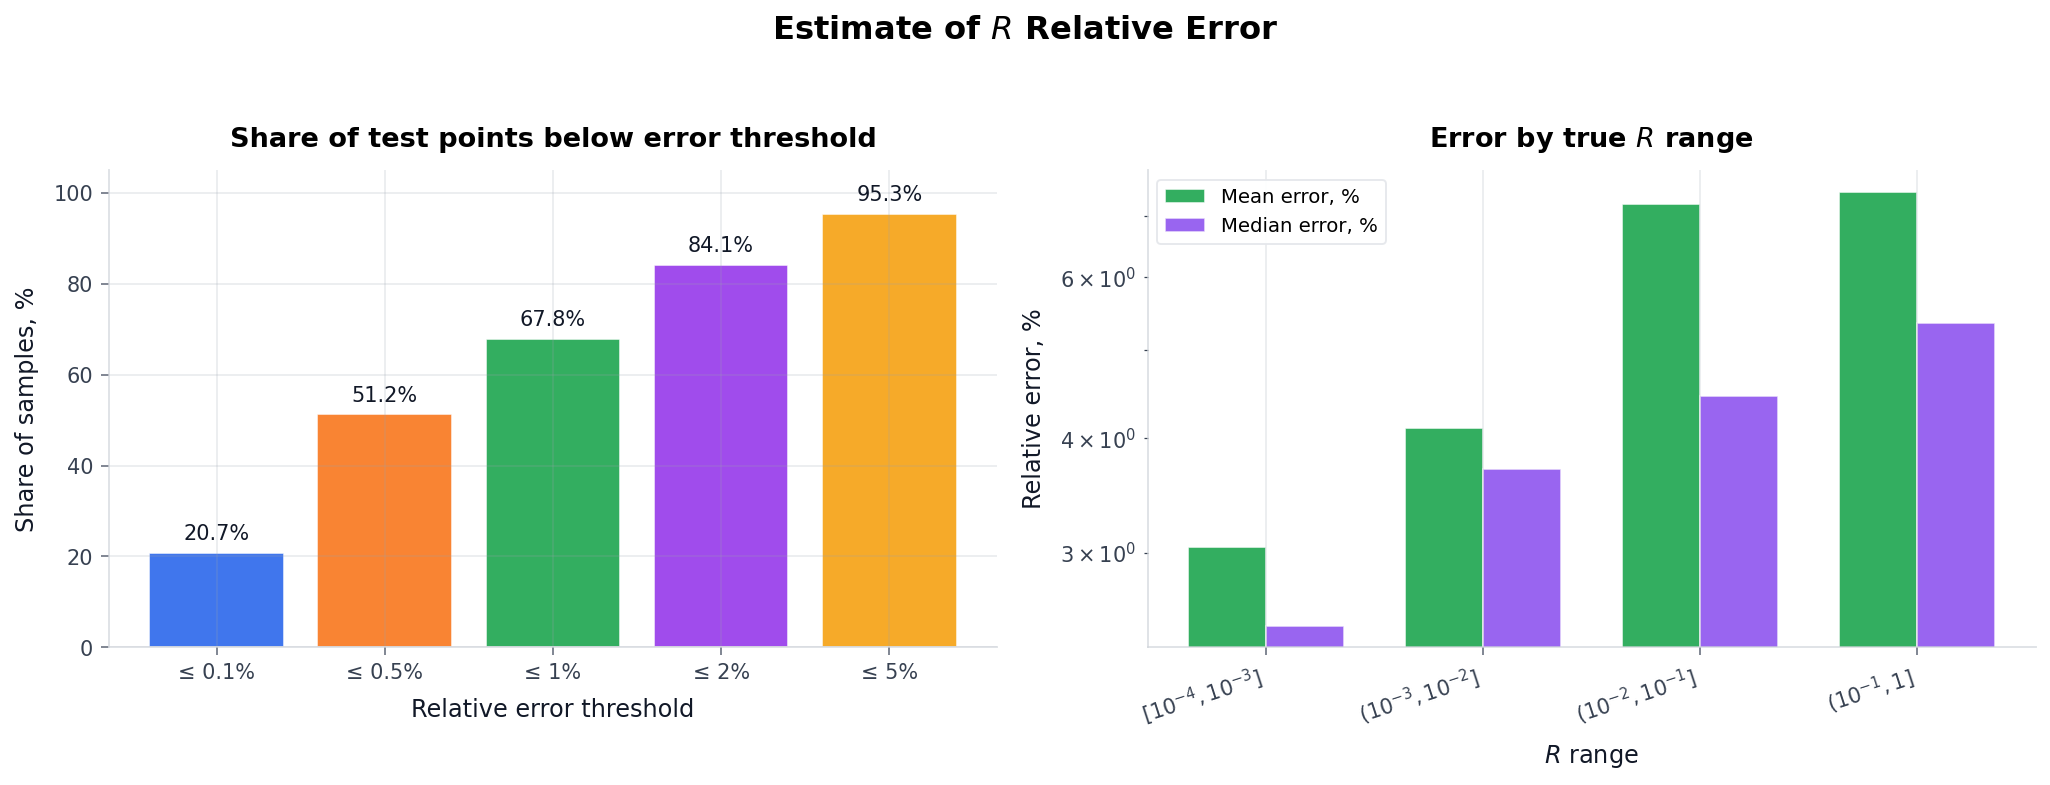

In [1447]:
rel_R = rel_error_R_pct_all[np.isfinite(rel_error_R_pct_all)]
thresholds = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
coverage = np.array([100.0 * np.mean(rel_R <= threshold) for threshold in thresholds])

coverage_df = pd.DataFrame({
    "threshold_percent": thresholds,
    "share_of_test_points_percent": coverage,
})

error_by_R = pd.DataFrame({
    "R_true": R_true_test[mask_rel],
    "relative_error_percent": rel_error_R_pct_all[mask_rel],
})

R_bins = [cfg.relative_error_min_R, 1e-3, 1e-2, 1e-1, np.inf]
R_bin_labels = [
    r"$[10^{-4}, 10^{-3}]$",
    r"$(10^{-3}, 10^{-2}]$",
    r"$(10^{-2}, 10^{-1}]$",
    r"$(10^{-1}, 1]$",
]

error_by_R["R_range"] = pd.cut(
    error_by_R["R_true"],
    bins=R_bins,
    labels=R_bin_labels,
    include_lowest=True,
)

range_summary = (
    error_by_R
    .groupby("R_range", observed=True)
    .agg(
        count=("relative_error_percent", "size"),
        mean_error_percent=("relative_error_percent", "mean"),
        median_error_percent=("relative_error_percent", "median"),
        share_error_below_1pct=("relative_error_percent", lambda x: 100.0 * np.mean(x <= 1.0)),
    )
    .reset_index()
)

display(range_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0), dpi=150)
fig.suptitle(r"Estimate of $R$ Relative Error", fontsize=15.5, fontweight="semibold", y=1.04)

bars = axes[0].bar(
    [f"≤ {x:g}%" for x in thresholds],
    coverage,
    color=[COLORS["train"], COLORS["valid"], COLORS["test"], COLORS["lbfgs"], COLORS["amber"]],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_ylim(0, 105)
for bar, value in zip(bars, coverage):
    axes[0].text(bar.get_x() + bar.get_width() / 2, min(value + 2.0, 103), f"{value:.1f}%", ha="center", va="bottom", fontsize=10, color="#111827")
polish_axes(axes[0], "Share of test points below error threshold", "Relative error threshold", "Share of samples, %")

x = np.arange(len(range_summary))
width = 0.36
axes[1].bar(
    x - width / 2,
    range_summary["mean_error_percent"],
    width=width,
    color=COLORS["reflection"],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
    label=r"Mean error, %",
)
axes[1].bar(
    x + width / 2,
    range_summary["median_error_percent"],
    width=width,
    color=COLORS["purple"],
    alpha=0.78,
    edgecolor="white",
    linewidth=0.8,
    label=r"Median error, %",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(range_summary["R_range"].astype(str), rotation=18, ha="right")
axes[1].set_yscale("log")
polish_axes(axes[1], r"Error by true $R$ range", r"$R$ range", "Relative error, %", legend=True)

plt.tight_layout()
save_current_figure(visualization_run_dir / "relative_error.png")
plt.show()

## Reflection Spectrum


,MAE,RMSE,"rMAE, %","rRMSE, %"
0,0.000231,0.003713,1.24601,2.47715


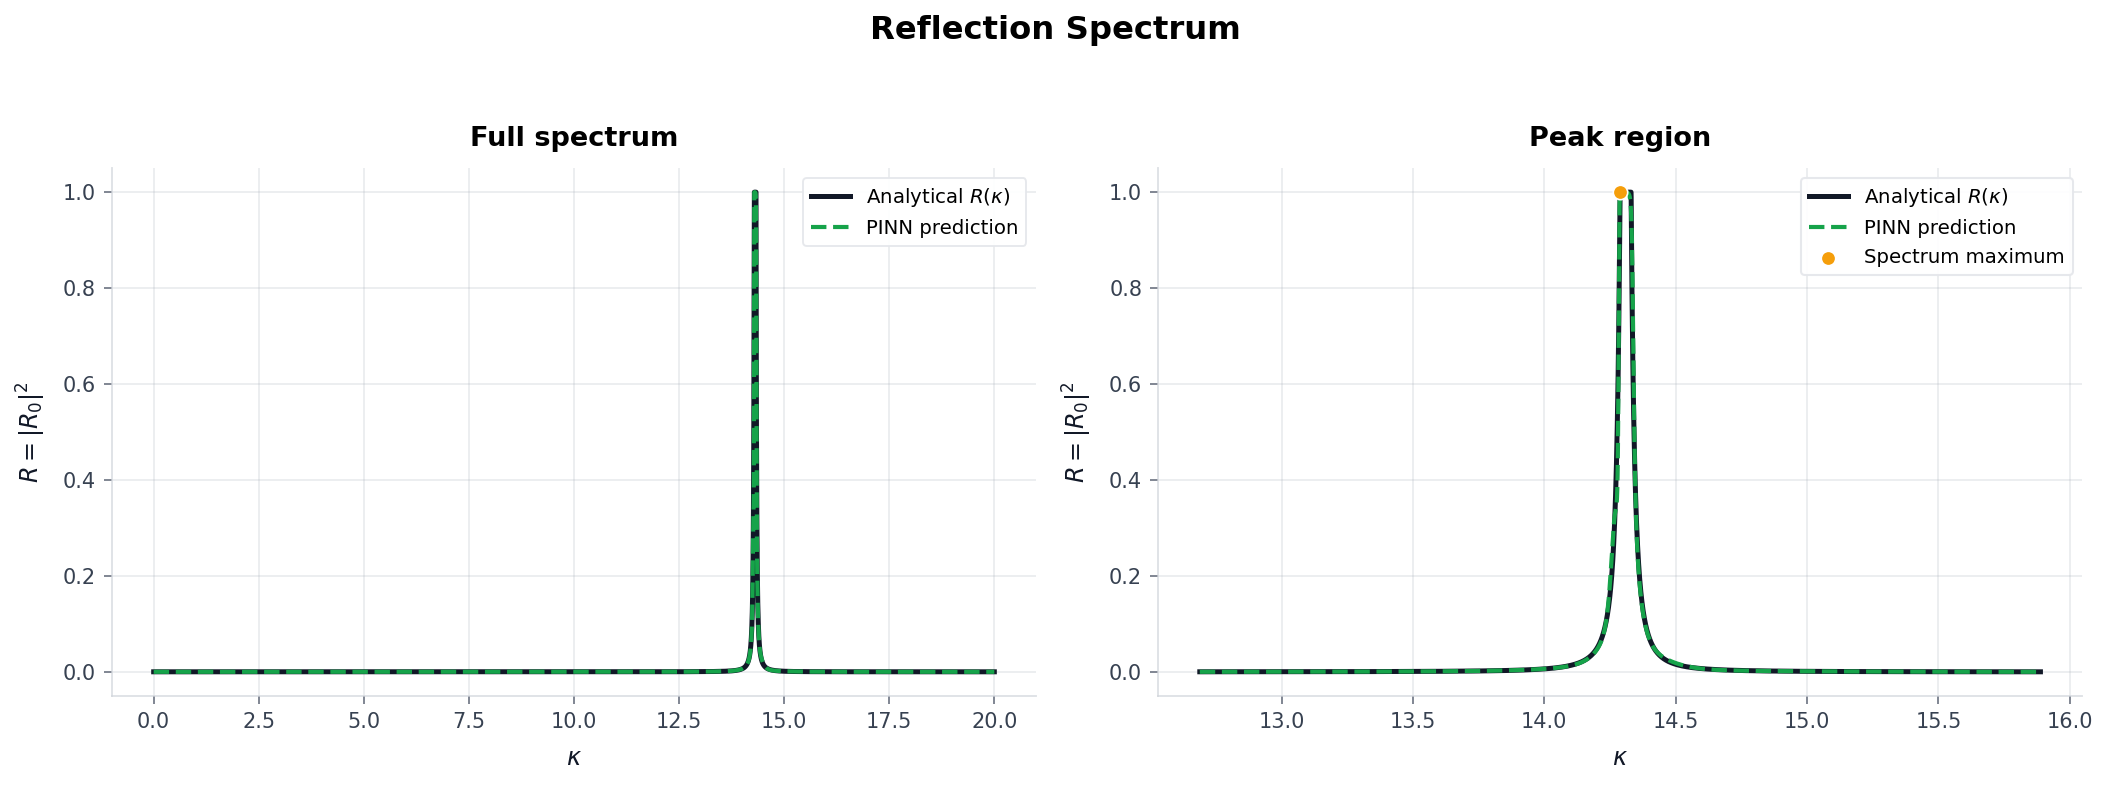

In [1448]:
@torch.no_grad()
def predict_spectrum(spectrum_df: pd.DataFrame) -> np.ndarray:
    X_spectrum_raw = build_features(spectrum_df)[feature_cols]
    X_spectrum = torch.tensor(x_scaler.transform(X_spectrum_raw), dtype=torch.float32, device=device)
    return predict_R_dataset(model, X_spectrum)


spectrum_df = df.sort_values("kappa").reset_index(drop=True)
R_spectrum_true = spectrum_df["R"].to_numpy()
R_spectrum_pred = predict_spectrum(spectrum_df)
spectrum_abs_error = np.abs(R_spectrum_pred - R_spectrum_true)
spectrum_rel_error = 100.0 * spectrum_abs_error / np.maximum(np.abs(R_spectrum_true), cfg.relative_error_min_R)
spectrum_metrics = regression_metrics(R_spectrum_true, R_spectrum_pred, rel_eps=cfg.relative_error_min_R)

spectrum_metrics_df = pd.DataFrame([{
    "MAE": spectrum_metrics["MAE"],
    "RMSE": spectrum_metrics["RMSE"],
    "rMAE, %": 100.0 * spectrum_metrics["rMAE"],
    "rRMSE, %": 100.0 * spectrum_metrics["rRMSE"],
}])
display(spectrum_metrics_df)

peak_idx = int(np.argmax(R_spectrum_true))
peak_kappa = float(spectrum_df["kappa"].iloc[peak_idx])
peak_R = float(R_spectrum_true[peak_idx])

kappa_values = spectrum_df["kappa"].to_numpy()
zoom_width = max(0.75, 0.08 * (kappa_values.max() - kappa_values.min()))
zoom_left = max(kappa_values.min(), peak_kappa - zoom_width)
zoom_right = min(kappa_values.max(), peak_kappa + zoom_width)
zoom_mask = (kappa_values >= zoom_left) & (kappa_values <= zoom_right)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), dpi=150)
fig.suptitle(r"Reflection Spectrum", fontsize=15.5, fontweight="semibold", y=1.04)

for ax, mask, title in [
    (axes[0], np.ones_like(kappa_values, dtype=bool), r"Full spectrum"),
    (axes[1], zoom_mask, r"Peak region"),
]:
    ax.plot(
        kappa_values[mask],
        R_spectrum_true[mask],
        color=COLORS["ideal"],
        linewidth=2.4,
        label=r"Analytical $R(\kappa)$",
    )
    ax.plot(
        kappa_values[mask],
        R_spectrum_pred[mask],
        color=COLORS["reflection"],
        linewidth=2.0,
        linestyle="--",
        label="PINN prediction",
    )
    polish_axes(ax, title, r"$\kappa$", r"$R=|R_0|^2$", legend=True)

axes[1].scatter(
    [peak_kappa],
    [peak_R],
    s=48,
    color=COLORS["amber"],
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
    label="Spectrum maximum",
)
axes[1].legend()

plt.tight_layout()
save_current_figure(visualization_run_dir / "spectrum.png")
plt.show()

## Error Plot


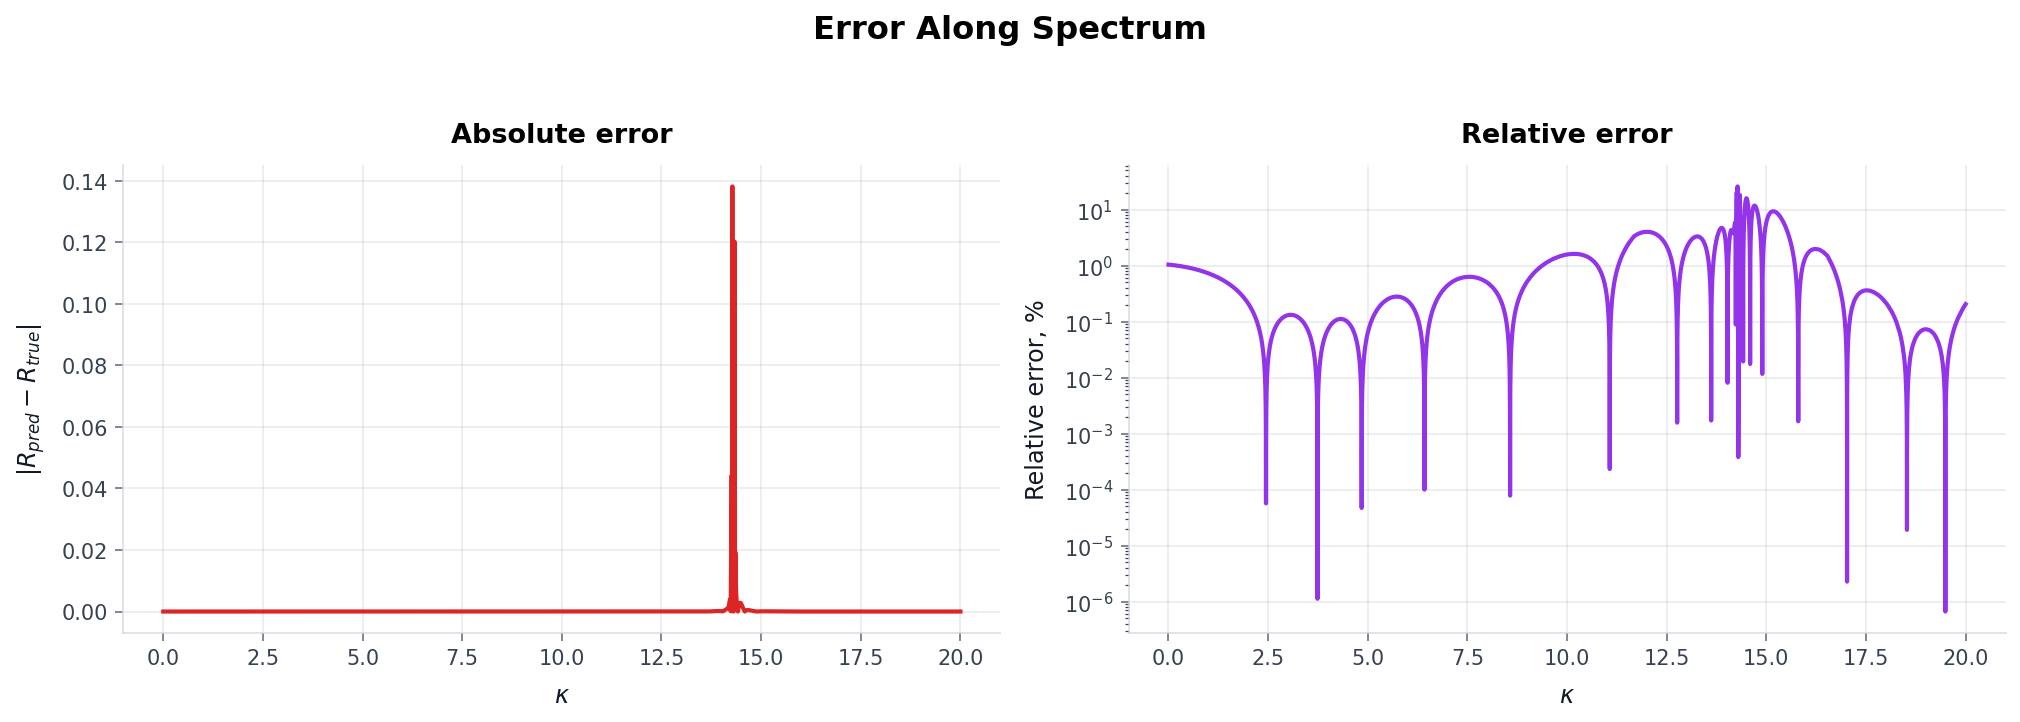

In [1449]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.6), dpi=150, sharex=True)
fig.suptitle("Error Along Spectrum", fontsize=15.5, fontweight="semibold", y=1.04)

axes[0].plot(spectrum_df["kappa"], spectrum_abs_error, color=COLORS["physics"], linewidth=2.0)
polish_axes(axes[0], r"Absolute error", r"$\kappa$", r"$|R_{pred}-R_{true}|$")

axes[1].plot(spectrum_df["kappa"], spectrum_rel_error, color=COLORS["lbfgs"], linewidth=2.0)
axes[1].set_yscale("log")
polish_axes(axes[1], r"Relative error", r"$\kappa$", "Relative error, %")

plt.tight_layout()
save_current_figure(visualization_run_dir / "error_spectrum.png")
plt.show()

## Save Model


In [1450]:
def config_to_serializable_dict(cfg: Config) -> dict:
    result = {}
    for key, value in asdict(cfg).items():
        result[key] = str(value) if isinstance(value, Path) else value
    return result


model.load_state_dict(best_state_dict)

checkpoint = {
    "model_state_dict": best_state_dict,
    "config": config_to_serializable_dict(cfg),
    "feature_cols": feature_cols,
    "target_cols": target_cols,
    "architecture": "PhysicsInformedNN",
    "x_scaler_mean": x_scaler.mean_,
    "x_scaler_scale": x_scaler.scale_,
    "y_scaler_mean": y_scaler.mean_,
    "y_scaler_scale": y_scaler.scale_,
    "metrics": {
        "metrics": metrics_df.to_dict(orient="records"),
        "spectrum_metrics": spectrum_metrics_df.to_dict(orient="records"),
        "selected_valid_loss": float(best_valid),
        "selected_stage": best_stage,
    },
    "noise": {
        "add_noise": cfg.add_noise,
        "noise_level": cfg.noise_level,
        "noise_percent": noise_percent,
        "noise_seed": cfg.noise_seed,
    },
    "n_objects": int(base_n_objects),
    "model_run_id": int(resolved_model_run_id),
    "visualization_run_dir": str(visualization_run_dir),
    "dataset_accounting": {
        "dataset_rows": int(base_n_objects),
        "train_rows": int(len(idx_train)),
        "validation_rows": int(len(idx_valid)),
        "test_rows": int(len(idx_test)),
    },
    "seed": SEED,
}

if model_was_loaded:
    print(f"Loaded model without overwriting: {checkpoint_path}")
elif cfg.save_model_after_training:
    torch.save(checkpoint, model_path)
    print(f"Saved model: {model_path}")
else:
    print("Model saving skipped")

Saved model: c:\Users\IlyaApokorin\Reflection-Coefficient-PINN\PINN\saved_models\noise_5\pinn_ws4_N50k_h64x3_bs4096_ep2000_lr0p0005_m03.pt
